# Elastic scattering with `LocalOpticalPotential`

`LocalOpticalPotential` provides a useful interface for defining optical potentials. 

In [1]:
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt
from pandas import DataFrame

In [2]:
from jitr.reactions.reaction import Reaction
from jitr.utils import utils
from jitr.rmatrix import Solver as SolverKernel
from jitr.xs import elastic
from jitr.optical_potentials import LocalOpticalPotential

In [3]:
neutron = (1, 0)
proton = (1, 1)

In [4]:
target = (208, 82)
projectile = proton
energy_lab = 24
reaction = Reaction(target=target, projectile=projectile, process="El")
kinematics = reaction.kinematics(energy_lab)

In [5]:
# set the channel radius, number of nodes, and number of partial waves
interaction_range_fm = 1.2 * (208 ** (1 / 3)) + 1
channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
    interaction_range_fm, kinematics.k
)
channel_radius = channel_radius_dimensionless / kinematics.k
N = utils.suggested_basis_size(channel_radius_dimensionless)
lmax = 50

In [6]:
# build a solver for the system and reaction of interest
print(f"Compiling solver for {reaction} at {energy_lab} MeV")
print(f" - channel radius {channel_radius:1.2f} fm")
print(f" - {N} nodes")
print(f" - {lmax} partial waves")

solver = elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius,
    solver=SolverKernel(N),
    lmax=lmax,
    angles=np.linspace(0.1, np.pi, 180),
)
rgrid = solver.radial_grid()
print("Done!")

Compiling solver for 208-Pb(p,el) at 24 MeV
 - channel radius 13.94 fm
 - 25 nodes
 - 50 partial waves
Done!


## Use the built-in `LocalOpticalPotential` class

Although, in general, one can define whatever interaction they want. This is just a handy tool.

In [7]:
omp = LocalOpticalPotential()
omp.params

['Vv',
 'rv',
 'av',
 'Wv',
 'rw',
 'aw',
 'Wd',
 'Vd',
 'rd',
 'ad',
 'Vso',
 'Wso',
 'rso',
 'aso',
 'rC']

## Randomly generate a bunch of parameters

In [8]:
means = np.array([56, 1.2, 0.7, 5, 1.2, 0.7, 13, 6, 1.3, 0.9, 8, 4, 1.1, 0.7, 1.2])
std_devs = np.array(
    [3, 0.05, 0.03, 0.1, 0.05, 0.05, 1, 0.1, 0.1, 0.1, 0.2, 1, 0.1, 0.05, 0.1]
)
samples = np.random.multivariate_normal(means, np.diag(std_devs) ** 2, 1000)

In [9]:
df = DataFrame(samples, columns=omp.params)
df.head()

,Vv,rv,av,Wv,rw,aw,Wd,Vd,rd,ad,Vso,Wso,rso,aso,rC
0,51.100403,1.193229,0.694053,5.001168,1.204845,0.698625,11.593592,6.002358,1.180502,0.987147,8.170491,3.076880,1.085694,0.734179,1.339886
1,52.833976,1.219670,0.686945,4.859437,1.260052,0.711278,11.806969,5.940825,1.241372,0.904550,8.085328,4.380284,1.151938,0.721191,1.342671
2,60.490654,1.111695,0.690334,5.017723,1.266576,0.709783,11.567632,6.207810,1.380022,0.802054,8.088928,3.947422,1.042329,0.771521,1.315199
3,55.871365,1.194629,0.746419,5.118907,1.167164,0.682690,13.338335,6.052000,1.309950,0.599037,7.906294,4.470666,1.194999,0.675212,1.157940
4,55.460503,1.117543,0.733219,4.896455,1.210000,0.658962,14.617597,6.307500,1.341588,0.890594,8.172465,4.120561,1.102040,0.620034,1.185585


## How do we calculate observables? 
We are using a `jitr.xs.elastic.DifferentialWorkspace`, which is set up specifically to interface with `omp` and other classes that have the same structure

In [10]:
help(elastic.DifferentialWorkspace.xs)

Help on function xs in module jitr.xs.elastic:

xs(self, central_potential: 'npt.ArrayLike', spin_orbit_potential: 'npt.ArrayLike | None' = None, coulomb_potential: 'npt.ArrayLike | None' = None) -> 'ElasticXS'
    Return differential and integral elastic observables.



Exactly the information that the solver workspace needs is what is provided by the `omp` class:

In [11]:
help(omp.evaluate)

Help on method evaluate in module jitr.optical_potentials.omp:

evaluate(rgrid: 'ArrayOrScalar', reaction_model: 'reaction.Reaction', kinematics_model: 'kinematics.ChannelKinematics', Vv: 'float', rv: 'float', av: 'float', Wv: 'float', rw: 'float', aw: 'float', Wd: 'float', Vd: 'float', rd: 'float', ad: 'float', Vso: 'float', Wso: 'float', rso: 'float', aso: 'float', rC: 'float') -> 'tuple[PotentialArray, PotentialArray, PotentialArray | ArrayOrScalar]' method of jitr.optical_potentials.omp.LocalOpticalPotential instance
    Evaluate the local optical-potential terms on ``rgrid``.



## Do you see the vision?

Now running calculations is simple!
Once it's been compiled, it's fast:

In [12]:
%%time
num_samples, num_params = df.shape
xs_ratio = np.zeros((num_samples, solver.angles.size))
Ay = np.zeros((num_samples, solver.angles.size))
rgrid = solver.radial_grid()

for i in tqdm(range(num_samples)):
    central_term, spin_orbit_term, coulomb_term = omp(
        rgrid,
        reaction,
        kinematics,
        *samples[i, :],
    )
    xs = solver.xs(central_term, spin_orbit_term, coulomb_term)
    xs_ratio[i, :] = xs.dsdo / solver.rutherford
    Ay[i, :] = xs.Ay

100%|██████████████████████████████████████████████████████████| 1000/1000 [00:09<00:00, 100.51it/s]

CPU times: user 9.68 s, sys: 265 ms, total: 9.94 s
Wall time: 9.95 s


Text(0, 0.5, '$\\frac{d \\sigma}{d\\Omega} / \\frac{d \\sigma_{\\text{R}}}{d\\Omega}$ [dimensionless]')

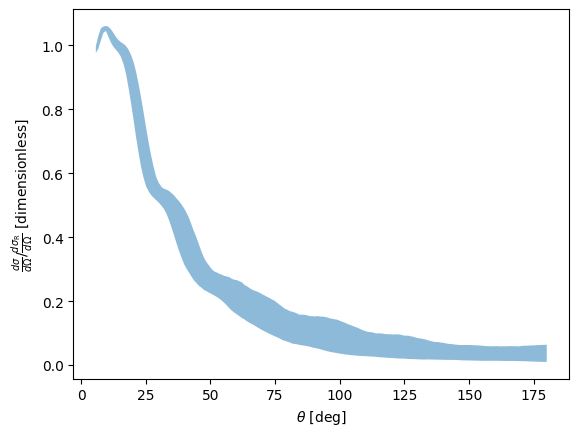

In [13]:
plt.fill_between(
    np.rad2deg(solver.angles), *np.percentile(xs_ratio, [5, 95], axis=0), alpha=0.5
)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(
    r"$\frac{d \sigma}{d\Omega} / \frac{d \sigma_{\text{R}}}{d\Omega}$ [dimensionless]"
)

Text(0, 0.5, '$A_y$ [dimensionless]')

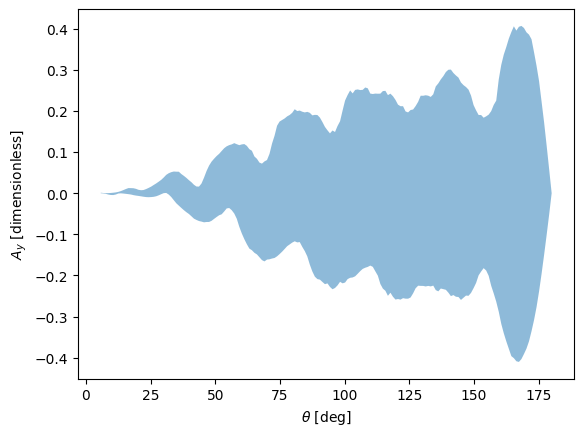

In [14]:
plt.fill_between(
    np.rad2deg(solver.angles), *np.percentile(Ay, [5, 95], axis=0), alpha=0.5
)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$A_y$ [dimensionless]")